### Visión por Computadora — TP2

Autor: Nicolás Rodrigues da Cruz (a2123)

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

VIDEO = Path('../Material_TPs/TP2/focus_video.mov') 

#### Punto 1

Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain“ y realizar tres experimentos:

a) Medición sobre todo el frame

In [ ]:
def fm_sharpness_frequency(gray: np.ndarray, thresh_factor: float = 1000.0) -> float:
    F  = np.fft.fft2(gray)
    Fc = np.fft.fftshift(F)
    AF = np.abs(Fc)
    Mmax = AF.max()
    if Mmax <= 0:
        return 0.0
    thres = Mmax / float(thresh_factor)
    TH = np.count_nonzero(AF > thres)
    FM = TH / float(gray.size)
    return float(FM)

In [9]:
cap = cv.VideoCapture(str(VIDEO))
scores, frames_rgb = [], []
while True:
    ok, frame = cap.read()
    if not ok:
        break
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    scores.append(fm_sharpness_frequency(gray))
    frames_rgb.append(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
cap.release()

scores = np.array(scores, dtype=float)
best_i = int(np.argmax(scores)) if len(scores) else -1
print(f"Mejor enfoque (full frame): frame {best_i}  |  FM={scores[best_i]:.6f}" if best_i>=0 else "Sin frames")

Mejor enfoque (full frame): frame 109  |  FM=0.028624


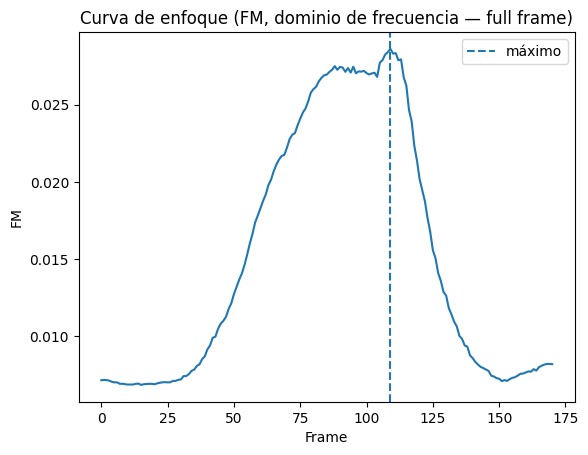

In [10]:
x = np.arange(len(scores))
plt.plot(x, scores)
if best_i >= 0:
    plt.axvline(best_i, linestyle='--', label='máximo')
plt.title('Curva de enfoque (FM, dominio de frecuencia — full frame)')
plt.xlabel('Frame'); plt.ylabel('FM'); plt.legend(); plt.show()

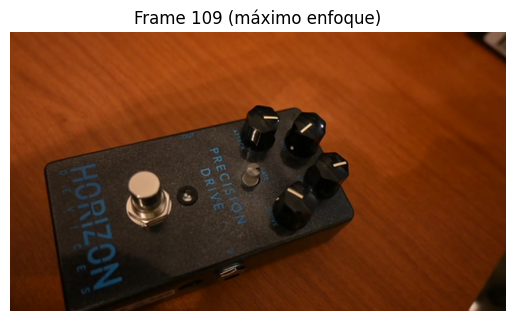

In [11]:
if best_i >= 0:
    plt.imshow(frames_rgb[best_i]); plt.title(f'Frame {best_i} (máximo enfoque)'); plt.axis('off'); plt.show()

- La curva FM muestra un máximo claro en el frame 109, coherente con la transición que se ve en el video de desenfocado→enfocado→desenfocado.

- En los laterales de la curva se observa menor FM (poca energía alta) por el blur; alrededor del máximo se ve una meseta pequeña por microvariaciones del enfoque o compresión del video.

b) Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.

In [12]:
def center_roi(gray: np.ndarray, frac: float = 0.10) -> np.ndarray:
    h, w = gray.shape
    dh, dw = int(h*frac/2), int(w*frac/2)
    cy, cx = h//2, w//2
    return gray[cy-dh:cy+dh, cx-dw:cx+dw]

In [19]:
# Loop del video midiendo sobre una ROI en el centro del frame
roi_frac = 0.10 

cap = cv.VideoCapture(str(VIDEO))
scores_roi, frames_rgb = [], []
rects = []

while True:
    ok, frame = cap.read()
    if not ok:
        break
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

    # recorto ROI central
    h, w = gray.shape
    dh, dw = int(h*roi_frac/2), int(w*roi_frac/2)
    cy, cx = h//2, w//2
    y1, y2 = cy-dh, cy+dh
    x1, x2 = cx-dw, cx+dw
    roi = gray[y1:y2, x1:x2]

    score = fm_sharpness_frequency(roi)
    scores_roi.append(score)
    frames_rgb.append(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
    rects.append((x1, y1, x2, y2))

cap.release()

scores_roi = np.array(scores_roi, dtype=float)
best_i_roi = int(np.argmax(scores_roi)) if len(scores_roi) else -1
print(f"Mejor enfoque (ROI {int(roi_frac*100)}%): frame {best_i_roi} | FM={scores_roi[best_i_roi]:.6f}" if best_i_roi>=0 else "Sin frames")

Mejor enfoque (ROI 10%): frame 91 | FM=0.738715


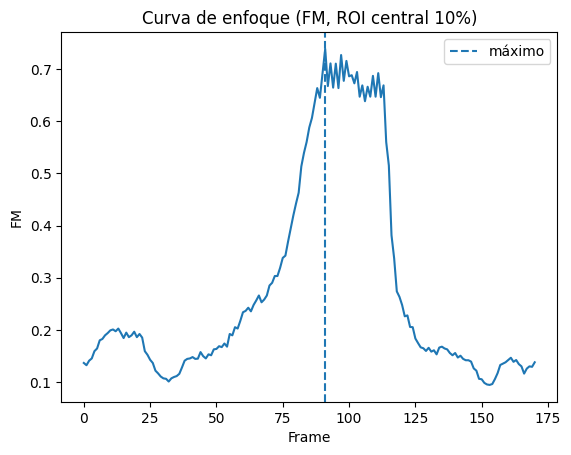

In [20]:
plt.plot(np.arange(len(scores_roi)), scores_roi)
if best_i_roi >= 0:
    plt.axvline(best_i_roi, linestyle='--', label='máximo')
plt.title(f'Curva de enfoque (FM, ROI central {int(roi_frac*100)}%)')
plt.xlabel('Frame'); plt.ylabel('FM'); plt.legend(); plt.show()

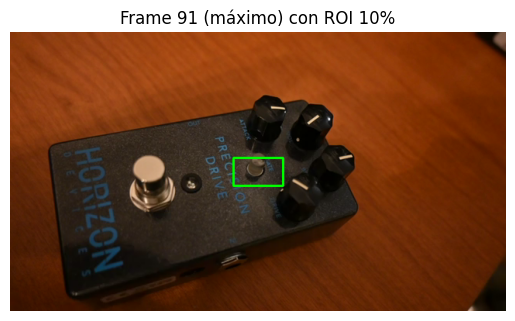

In [21]:
#Mostramos la curva de FM para la ROI y el frame ganador con el rectangulo de la ROI dibujado.
if best_i_roi >= 0:
    vis = frames_rgb[best_i_roi].copy()
    x1, y1, x2, y2 = rects[best_i_roi]
    # dibujar rectangulo ROI (en RGB para matplotlib)
    vis_bgr = cv.cvtColor(vis, cv.COLOR_RGB2BGR)
    cv.rectangle(vis_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)  # verde
    vis = cv.cvtColor(vis_bgr, cv.COLOR_BGR2RGB)

    plt.imshow(vis)
    plt.title(f'Frame {best_i_roi} (máximo) con ROI {int(roi_frac*100)}%')
    plt.axis('off'); plt.show()

En el experimento 2 (ROI) el máximo se detectó en el frame 91, bastante alejado del anterior (109). Esto muestra que la métrica en ROI central puede ser poco confiable si la región elegida no concentra suficiente detalle.

c) Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores 
arbitrarios, probar con varios valores 3x3, 7x5, etc … (al menos 3)

In [22]:
def fm_grid_mean(gray: np.ndarray, grid=(3,3)) -> float:
    gh, gw = grid
    h,  w  = gray.shape
    dh, dw = h // gh, w // gw
    vals = []
    for r in range(gh):
        for c in range(gw):
            tile = gray[r*dh:(r+1)*dh, c*dw:(c+1)*dw]
            # por si no divide exacto, evitamos tiles vacíos
            if tile.size == 0: 
                continue
            vals.append(fm_sharpness_frequency(tile))
    return float(np.mean(vals)) if vals else 0.0

In [23]:
#Loop del video: aplicar FM promedio en rejilla NxM
grid = (3,3) 
cap = cv.VideoCapture(str(VIDEO))
scores_grid, frames_rgb = [], []

while True:
    ok, frame = cap.read()
    if not ok:
        break
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    score = fm_grid_mean(gray, grid=grid)
    scores_grid.append(score)
    frames_rgb.append(cv.cvtColor(frame, cv.COLOR_BGR2RGB))

cap.release()

scores_grid = np.array(scores_grid, dtype=float)
best_i_grid = int(np.argmax(scores_grid)) if len(scores_grid) else -1
print(f"Mejor enfoque (grid {grid[0]}x{grid[1]}): frame {best_i_grid} | FM={scores_grid[best_i_grid]:.6f}" if best_i_grid>=0 else "Sin frames")


Mejor enfoque (grid 3x3): frame 105 | FM=0.126200


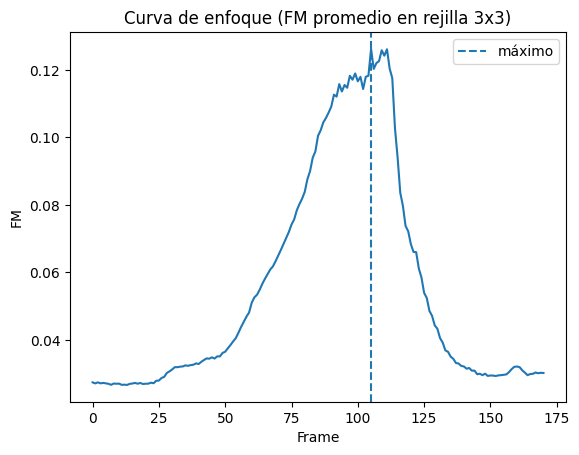

In [24]:
#Curva con máximo marcado
plt.plot(np.arange(len(scores_grid)), scores_grid)
if best_i_grid >= 0:
    plt.axvline(best_i_grid, linestyle='--', label='máximo')
plt.title(f'Curva de enfoque (FM promedio en rejilla {grid[0]}x{grid[1]})')
plt.xlabel('Frame'); plt.ylabel('FM'); plt.legend(); plt.show()

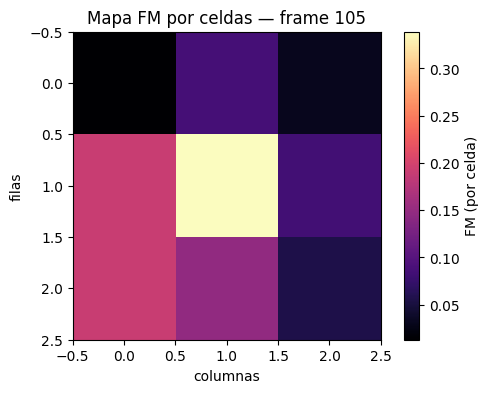

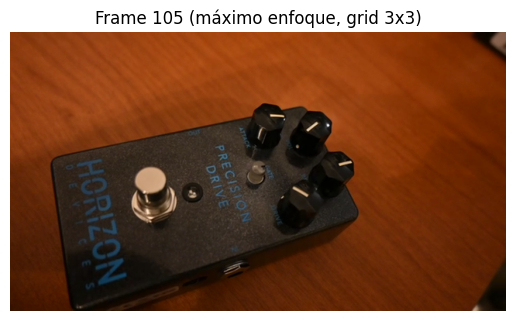

In [ ]:
#visualizamos el mapa de FM por celdas en el frame ganador
if best_i_grid >= 0:
    frame = cv.cvtColor(frames_rgb[best_i_grid], cv.COLOR_RGB2BGR)
    gray  = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    gh, gw = grid
    h, w  = gray.shape
    dh, dw = h // gh, w // gw
    heat = np.zeros((gh, gw), np.float32)

    for r in range(gh):
        for c in range(gw):
            tile = gray[r*dh:(r+1)*dh, c*dw:(c+1)*dw]
            if tile.size == 0: 
                continue
            heat[r, c] = fm_sharpness_frequency(tile)

    plt.figure(figsize=(6,4))
    plt.imshow(heat, cmap='magma')
    plt.colorbar(label='FM (por celda)')
    plt.title(f'Mapa FM por celdas — frame {best_i_grid}')
    plt.xlabel('columnas'); plt.ylabel('filas')
    plt.show()

    # Mostrar el frame ganador
    plt.imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
    plt.title(f'Frame {best_i_grid} (máximo enfoque, grid {grid[0]}x{grid[1]})')
    plt.axis('off'); plt.show()

En el experimento 3 (rejilla) el máximo se detectó en el frame 105. Este valor quedó más cercano al máximo visto en full frame (109) -que luego se vera que no era el máximo real- mostrando que la rejilla es más estable que la ROI. Al dividir la imagen en celdas se reduce la influencia de zonas irrelevantes, aunque el promedio puede verse afectado por sectores con poco detalle. En este caso, la rejilla corrigió parte del sesgo del ROI, pero no alcanzó la misma precisión que el resto de los métodos.


#### Punto 2

Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure 
operators in shapefrom focus.

In [26]:
def fm_brenner(gray: np.ndarray, both_axes: bool = True) -> float:
    g = gray.astype(np.float64)
    dh = g[2:, :] - g[:-2, :]
    val = (dh * dh).sum()
    if both_axes:
        dv = g[:, 2:] - g[:, :-2]
        val += (dv * dv).sum()
    return float(val / gray.size)

In [ ]:
cap = cv.VideoCapture(str(VIDEO))
scores_brenner, frames_rgb = [], []

while True:
    ok, frame = cap.read()
    if not ok:
        break
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    score = fm_brenner(gray, both_axes=True)  
    scores_brenner.append(score)
    frames_rgb.append(cv.cvtColor(frame, cv.COLOR_BGR2RGB))

cap.release()

scores_brenner = np.array(scores_brenner, dtype=float)
best_i = int(np.argmax(scores_brenner)) if len(scores_brenner) else -1
print(f"Mejor enfoque (Brenner, full): frame {best_i} | FM={scores_brenner[best_i]:.6f}" if best_i>=0 else "Sin frames")

Mejor enfoque (Brenner, full): frame 111 | FM=171.501636


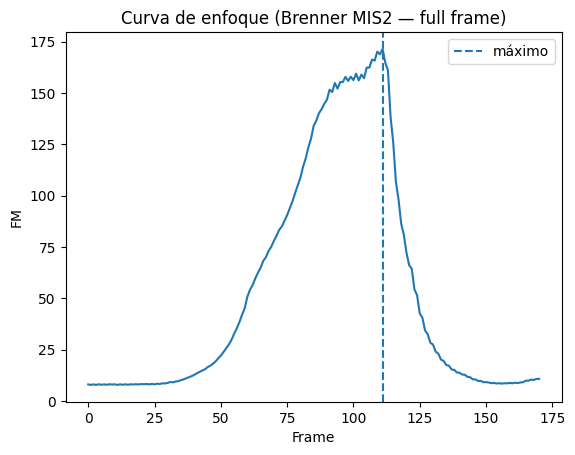

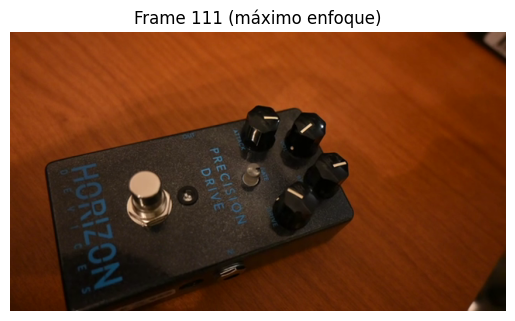

In [ ]:
#curva + máximo
x = np.arange(len(scores_brenner))
plt.plot(x, scores_brenner)
if best_i >= 0:
    plt.axvline(best_i, linestyle='--', label='máximo')
plt.title('Curva de enfoque (Brenner MIS2 — full frame)')
plt.xlabel('Frame'); plt.ylabel('FM'); plt.legend(); plt.show()

if best_i >= 0:
    plt.imshow(frames_rgb[best_i]); plt.title(f'Frame {best_i} (máximo enfoque)'); plt.axis('off'); plt.show()

Al aplicar Brenner (MIS2) como métrica alternativa se detectó el máximo en el frame 111 (el cual es el max real). Este operador funciona distinto a la métrica del paper: en lugar de analizar el contenido en el dominio de la frecuencia, Brenner mide la nitidez a partir de la segunda diferencia de intensidades entre píxeles separados dos posiciones. De esta manera, capta de forma directa la presencia de bordes y cambios bruscos en la imagen. 

#### Punto Bonus

Aplicar unsharp masking para expandir la zona de enfoque y recalcular la métrica

In [29]:
def unsharp_mask(gray, k=1.0, sigma=1.0):
    blur = cv.GaussianBlur(gray, (0,0), sigmaX=sigma)
    mask = cv.subtract(gray, blur)
    g = cv.addWeighted(gray, 1.0, mask, k, 0.0)
    return g

In [30]:
#medir FM antes y después de unsharp
cap = cv.VideoCapture(str(VIDEO))
scores_before, scores_after, frames_rgb = [], [], []

while True:
    ok, frame = cap.read()
    if not ok: break
    gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
    scores_before.append(fm_sharpness_frequency(gray))
    sharp = unsharp_mask(gray, k=1.0, sigma=1.0) 
    scores_after.append(fm_sharpness_frequency(sharp))

    frames_rgb.append(cv.cvtColor(frame, cv.COLOR_BGR2RGB))

cap.release()

scores_before = np.array(scores_before, float)
scores_after  = np.array(scores_after,  float)

best_before = int(np.argmax(scores_before)) if len(scores_before) else -1
best_after  = int(np.argmax(scores_after))  if len(scores_after)  else -1

print(f"[Full] sin unsharp → frame {best_before}, FM={scores_before[best_before]:.6f}")
print(f"[Full] con unsharp → frame {best_after},  FM={scores_after[best_after]:.6f}")

[Full] sin unsharp → frame 109, FM=0.028624
[Full] con unsharp → frame 111,  FM=0.035386


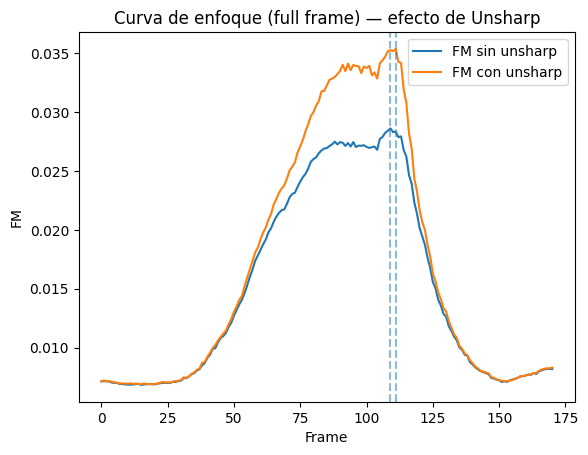

In [ ]:
#curvas comparadas
x = np.arange(len(scores_before))
plt.plot(x, scores_before, label='FM sin unsharp')
plt.plot(x, scores_after,  label='FM con unsharp')
plt.axvline(best_before, linestyle='--', alpha=0.5)
plt.axvline(best_after,  linestyle='--', alpha=0.5)
plt.title('Curva de enfoque (full frame) — efecto de Unsharp')
plt.xlabel('Frame'); plt.ylabel('FM'); plt.legend(); plt.show()

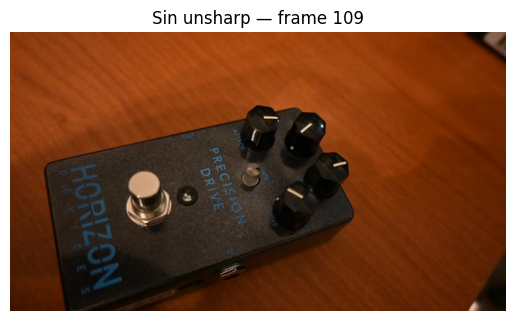

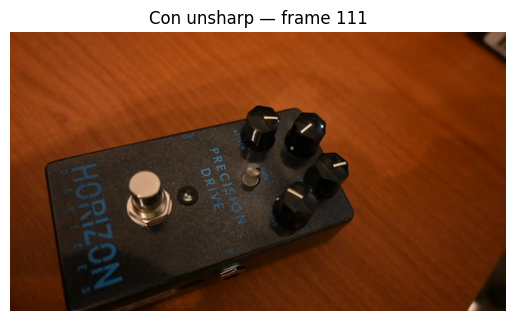

In [ ]:
#mostrar frames ganadores
if best_before >= 0:
    plt.imshow(frames_rgb[best_before]); plt.title(f'Sin unsharp — frame {best_before}'); plt.axis('off'); plt.show()
if best_after >= 0:
    plt.imshow(frames_rgb[best_after]);  plt.title(f'Con unsharp — frame {best_after}');  plt.axis('off'); plt.show()

En el experimento "bonus", ensancha la zona de alto enfoque, lo que facilita identificar el verdadero máximo en el frame 111. 
La técnica aporta estabilidad a la métrica y resalta con mayor claridad la región enfocada. 
En las imágenes se observa que aunque visualmente son bastante similares, la segunda presenta una nitidez levemente mayor, 
coherente con lo que marca la métrica.

#### Conclusiones generales

Los distintos experimentos muestran cómo varía la detección del máximo de enfoque según la estrategia utilizada. 
El método en frecuencia sobre el frame completo dio un valor cercano al real, la ROI resultó poco confiable, 
la rejilla mostró mayor estabilidad, y Brenner confirmó el mismo máximo observado visualmente. 
Finalmente, el Unsharp permitió ensanchar la zona de foco y facilitar la identificación del frame correcto.

Tabla de resultados:

| Método                         | Frame detectado |
|--------------------------------|-----------------|
| FM (full frame)                | 109             |
| FM (ROI central 10%)           | 91              |
| FM (rejilla 3×3)               | 105             |
| Brenner (MIS2)                 | 111             |
| FM + Unsharp Masking (extra)   | 111             |